# Module 0: Introduction to Machine Learning Fundamentals

**Learning Objectives:**
- Understand what Machine Learning is and how it differs from traditional programming
- Load and explore datasets using Python
- Understand the structure of data: Feature Matrix (X) and Labels (y)
- Distinguish between Classification and Regression tasks
- Learn why and how we split data into Training, Validation, and Test sets
- See the complete ML workflow from data to prediction

In [1]:
# Import libraries we'll use throughout this module
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_diabetes
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(42)

# Configure plot style
plt.style.use('seaborn-v0_8-whitegrid')

/Users/shivin/miniconda/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Part A: What is Machine Learning?

### Traditional Programming vs Machine Learning

**Traditional Programming:**
```
Input Data + Rules → Program → Output
```
You explicitly tell the computer what to do with `if-else` statements, formulas, etc.

**Machine Learning:**
```
Input Data + Expected Output → ML Algorithm → Learned Rules (Model)
```
The computer *learns* the rules by looking at examples!

---

### Supervised Learning (Our Focus)

In **supervised learning**, we have:
- **Input features (X)**: The information we use to make predictions
- **Labels/Targets (y)**: The correct answers we want to predict

The model learns the relationship between X and y from training examples, then uses this knowledge to predict y for new, unseen X values.

---

### The ML Workflow at a Glance

```
┌─────────────┐    ┌─────────────┐    ┌─────────────┐    ┌─────────────┐
│   Collect   │ →  │   Prepare   │ →  │    Train    │ →  │   Evaluate  │
│    Data     │    │    Data     │    │    Model    │    │    Model    │
└─────────────┘    └─────────────┘    └─────────────┘    └─────────────┘
                          ↓                  ↓                  ↓
                    Split into         Learn patterns      Test on unseen
                    X and y            from training       data
                                       examples
```

## Part B: Data - The Foundation of Machine Learning

Without data, there is no machine learning. Let's learn how to:
1. Load data from different sources
2. Explore and understand our data
3. Structure data into the format ML algorithms expect

---

### The Iris Dataset

We'll use the famous **Iris dataset** - a classic beginner dataset in ML:
- **150 samples** of iris flowers
- **4 features**: sepal length, sepal width, petal length, petal width (all in cm)
- **3 classes**: Setosa, Versicolor, Virginica (species of iris)

Let's load and explore it!

In [2]:
# Load the Iris dataset from sklearn
iris = load_iris()

# Convert to a pandas DataFrame for easier exploration
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target  # Add the target labels
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Display basic information
print("=" * 60)
print("IRIS DATASET OVERVIEW")
print("=" * 60)
print(f"\nDataset description: {iris.DESCR[:200]}...\n")
print(f"Number of samples: {len(df)}")
print(f"Number of features: {len(iris.feature_names)}")
print(f"Feature names: {iris.feature_names}")
print(f"Target classes: {iris.target_names}")
print(f"\nSamples per class:")
print(df['species_name'].value_counts())

IRIS DATASET OVERVIEW

Dataset description: .. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive...

Number of samples: 150
Number of features: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']

Samples per class:
setosa        50
versicolor    50
virginica     50
Name: species_name, dtype: int64


In [3]:
# Exploring the data: shape, head, describe

print("=" * 60)
print("DATA EXPLORATION")
print("=" * 60)

# 1. Shape: How many rows and columns?
print(f"\n1. SHAPE: {df.shape}")
print(f"   → {df.shape[0]} samples (rows), {df.shape[1]} columns (features + target)")

# 2. Head: What does the data look like?
print("\n2. FIRST 10 ROWS (head):")
print(df.head(10))

# 3. Describe: What are the statistics?
print("\n3. STATISTICAL SUMMARY (describe):")
print(df.describe())

DATA EXPLORATION

1. SHAPE: (150, 6)
   → 150 samples (rows), 6 columns (features + target)

2. FIRST 10 ROWS (head):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

   species s

### Understanding Samples and Features

In Machine Learning, we organize our data into:

**Feature Matrix (X):**
- Each **row** = one **sample** (a single observation/example)
- Each **column** = one **feature** (a measurable property)
- Shape: (n_samples, n_features)

**Label Vector (y):**
- Contains the **target/output** we want to predict
- One value per sample
- Shape: (n_samples,)

```
Feature Matrix X                           Label Vector y
┌──────────────────────────────────────┐   ┌───────────┐
│ sepal_len  sepal_wid  petal_len  ... │   │  species  │
├──────────────────────────────────────┤   ├───────────┤
│   5.1        3.5        1.4      ... │ → │     0     │  (setosa)
│   4.9        3.0        1.4      ... │ → │     0     │  (setosa)
│   7.0        3.2        4.7      ... │ → │     1     │  (versicolor)
│   6.3        3.3        6.0      ... │ → │     2     │  (virginica)
│   ...        ...        ...      ... │   │    ...    │
└──────────────────────────────────────┘   └───────────┘
      (150 samples × 4 features)              (150,)
```

FEATURE MATRIX (X) AND LABELS (y)

Feature Matrix X:
  Shape: (150, 4)
  → 150 samples, 4 features
  Type: ndarray

  First 5 samples:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Label Vector y:
  Shape: (150,)
  → 150 labels (one per sample)
  Unique values: [0 1 2] (0=setosa, 1=versicolor, 2=virginica)

  First 15 labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


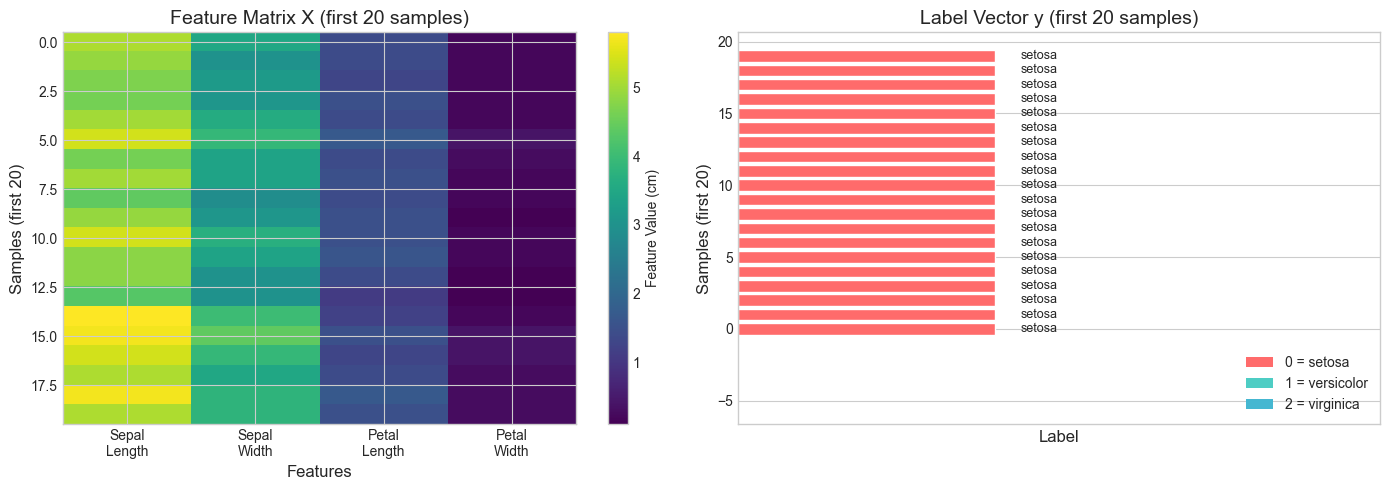


Key Insight: X contains the information, y contains the answers!
The ML model learns to map X → y


In [4]:
# Separate features (X) and labels (y)
X = iris.data  # Feature matrix
y = iris.target  # Label vector

print("=" * 60)
print("FEATURE MATRIX (X) AND LABELS (y)")
print("=" * 60)

print(f"\nFeature Matrix X:")
print(f"  Shape: {X.shape}")
print(f"  → {X.shape[0]} samples, {X.shape[1]} features")
print(f"  Type: {type(X).__name__}")
print(f"\n  First 5 samples:")
print(X[:5])

print(f"\nLabel Vector y:")
print(f"  Shape: {y.shape}")
print(f"  → {y.shape[0]} labels (one per sample)")
print(f"  Unique values: {np.unique(y)} (0=setosa, 1=versicolor, 2=virginica)")
print(f"\n  First 15 labels: {y[:15]}")

# Visualize the data structure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Visualize X matrix as heatmap
ax1 = axes[0]
im = ax1.imshow(X[:20], aspect='auto', cmap='viridis')
ax1.set_xlabel('Features', fontsize=12)
ax1.set_ylabel('Samples (first 20)', fontsize=12)
ax1.set_xticks(range(4))
ax1.set_xticklabels(['Sepal\nLength', 'Sepal\nWidth', 'Petal\nLength', 'Petal\nWidth'])
ax1.set_title('Feature Matrix X (first 20 samples)', fontsize=14)
plt.colorbar(im, ax=ax1, label='Feature Value (cm)')

# Right: Visualize y labels
ax2 = axes[1]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for i in range(20):
    ax2.barh(19-i, 1, color=colors[y[i]], edgecolor='white', height=0.8)
    ax2.text(1.1, 19-i, f'{iris.target_names[y[i]]}', va='center', fontsize=9)
ax2.set_xlim(0, 2.5)
ax2.set_xlabel('Label', fontsize=12)
ax2.set_ylabel('Samples (first 20)', fontsize=12)
ax2.set_title('Label Vector y (first 20 samples)', fontsize=14)
ax2.set_xticks([])

# Add legend
for i, name in enumerate(iris.target_names):
    ax2.barh(-5, 0, color=colors[i], label=f'{i} = {name}')
ax2.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

print("\nKey Insight: X contains the information, y contains the answers!")
print("The ML model learns to map X → y")

## Part C: Classification vs Regression

There are two main types of supervised learning tasks:

### Classification
**Goal:** Predict a **category/class** from a finite set of options

Examples:
- Email: Spam or Not Spam? (2 classes)
- Digit recognition: Which digit 0-9? (10 classes)
- Iris: Which species? (3 classes)
- Medical diagnosis: Disease type?

**The output is discrete/categorical.**

---

### Regression
**Goal:** Predict a **continuous numerical value**

Examples:
- House price prediction: $350,000, $425,500, ...
- Temperature forecasting: 23.5°C, 24.1°C, ...
- Stock price prediction
- Age estimation from photo

**The output is continuous/numerical.**

---

### How to Identify the Task Type?

Ask yourself: **"What type of answer am I predicting?"**

| If the answer is... | Then it's... |
|---------------------|---------------|
| A category (yes/no, type A/B/C) | **Classification** |
| A number on a continuous scale | **Regression** |

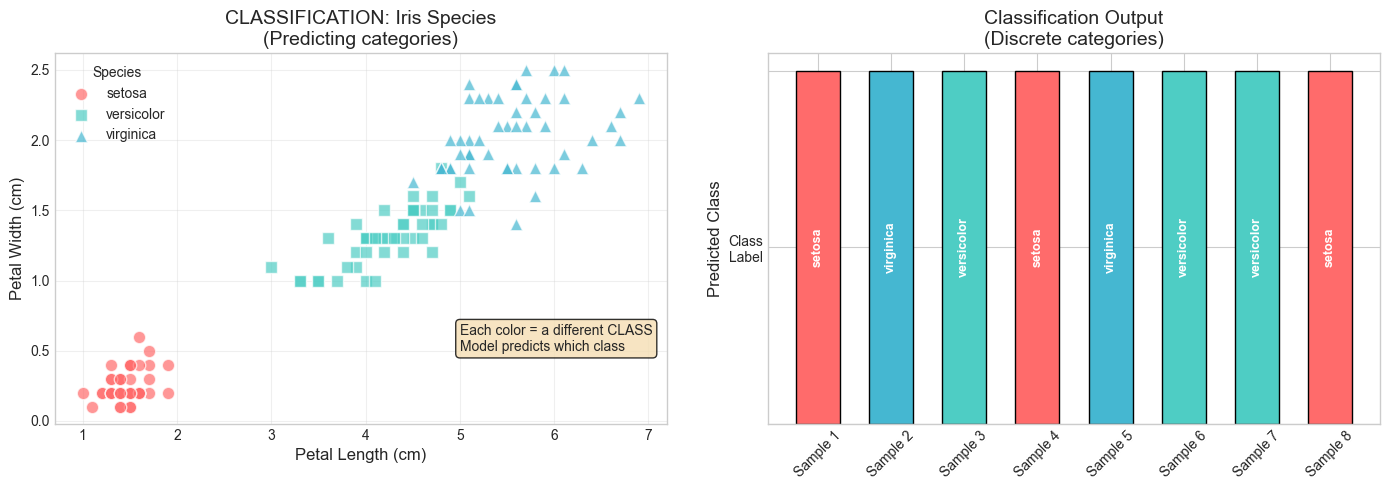

Classification: Output is one of a fixed set of categories
Iris has 3 possible classes: ['setosa', 'versicolor', 'virginica']


In [5]:
# Classification Example: Iris Dataset

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Classification visualization using 2 features
ax1 = axes[0]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
markers = ['o', 's', '^']

for i, (species, color, marker) in enumerate(zip(iris.target_names, colors, markers)):
    mask = y == i
    ax1.scatter(X[mask, 2], X[mask, 3], c=color, marker=marker, 
                s=80, alpha=0.7, edgecolors='white', linewidth=1,
                label=species)

ax1.set_xlabel('Petal Length (cm)', fontsize=12)
ax1.set_ylabel('Petal Width (cm)', fontsize=12)
ax1.set_title('CLASSIFICATION: Iris Species\n(Predicting categories)', fontsize=14)
ax1.legend(title='Species', fontsize=10)
ax1.grid(True, alpha=0.3)

# Add annotation
ax1.annotate('Each color = a different CLASS\nModel predicts which class', 
            xy=(5, 0.5), fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Plot 2: What classification output looks like
ax2 = axes[1]
sample_predictions = [0, 2, 1, 0, 2, 1, 1, 0]
sample_colors = [colors[p] for p in sample_predictions]
bars = ax2.bar(range(len(sample_predictions)), [1]*len(sample_predictions), 
               color=sample_colors, edgecolor='black', width=0.6)
ax2.set_xticks(range(len(sample_predictions)))
ax2.set_xticklabels([f'Sample {i+1}' for i in range(len(sample_predictions))], rotation=45)
ax2.set_ylabel('Predicted Class', fontsize=12)
ax2.set_title('Classification Output\n(Discrete categories)', fontsize=14)
ax2.set_yticks([0, 0.5, 1])
ax2.set_yticklabels(['', 'Class\nLabel', ''])

# Add class labels on bars
for i, pred in enumerate(sample_predictions):
    ax2.text(i, 0.5, iris.target_names[pred], ha='center', va='center', 
             fontsize=9, fontweight='bold', rotation=90, color='white')

plt.tight_layout()
plt.show()

print("Classification: Output is one of a fixed set of categories")
print(f"Iris has {len(iris.target_names)} possible classes: {list(iris.target_names)}")

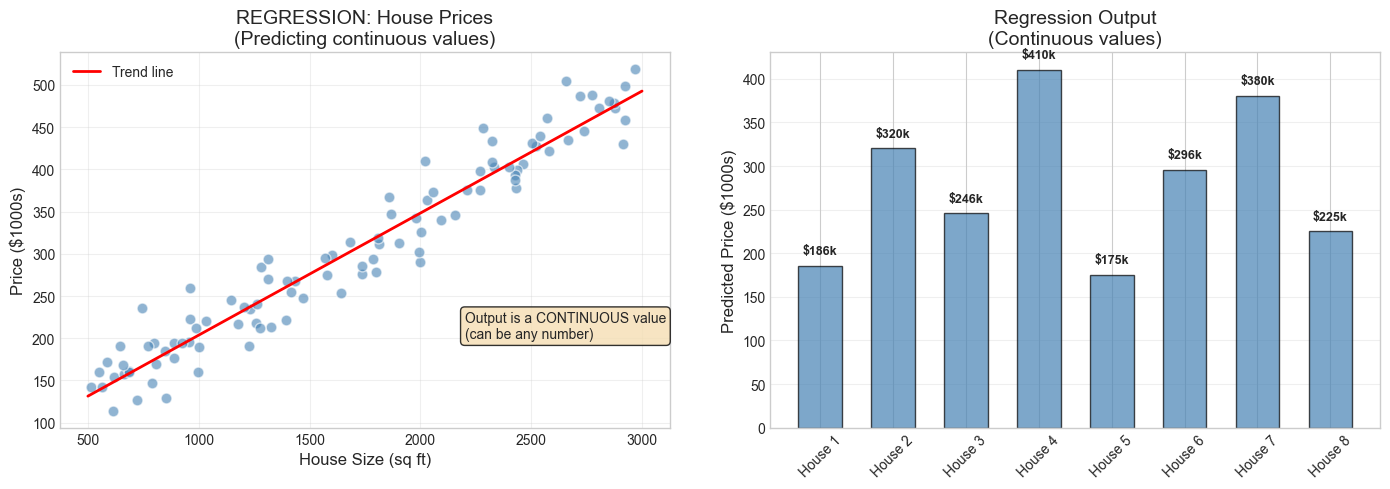

Regression: Output is a continuous numerical value
House prices can be any value: $185,500, $320,200, $245,800, ...


In [6]:
# Regression Example: Synthetic House Price Data

# Generate synthetic house price data
np.random.seed(42)
house_size = np.random.uniform(500, 3000, 100)  # Square feet
house_price = 50000 + 150 * house_size + np.random.normal(0, 30000, 100)  # Price in $

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Regression visualization
ax1 = axes[0]
ax1.scatter(house_size, house_price/1000, c='steelblue', s=60, alpha=0.6, edgecolors='white')

# Add trend line
z = np.polyfit(house_size, house_price/1000, 1)
p = np.poly1d(z)
x_line = np.linspace(500, 3000, 100)
ax1.plot(x_line, p(x_line), 'r-', linewidth=2, label='Trend line')

ax1.set_xlabel('House Size (sq ft)', fontsize=12)
ax1.set_ylabel('Price ($1000s)', fontsize=12)
ax1.set_title('REGRESSION: House Prices\n(Predicting continuous values)', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Add annotation
ax1.annotate('Output is a CONTINUOUS value\n(can be any number)', 
            xy=(2200, 200), fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Plot 2: What regression output looks like
ax2 = axes[1]
sample_predictions = [185.5, 320.2, 245.8, 410.1, 175.3, 295.7, 380.4, 225.0]
bars = ax2.bar(range(len(sample_predictions)), sample_predictions, 
               color='steelblue', edgecolor='black', width=0.6, alpha=0.7)
ax2.set_xticks(range(len(sample_predictions)))
ax2.set_xticklabels([f'House {i+1}' for i in range(len(sample_predictions))], rotation=45)
ax2.set_ylabel('Predicted Price ($1000s)', fontsize=12)
ax2.set_title('Regression Output\n(Continuous values)', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, pred in enumerate(sample_predictions):
    ax2.text(i, pred + 10, f'${pred:.0f}k', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("Regression: Output is a continuous numerical value")
print(f"House prices can be any value: $185,500, $320,200, $245,800, ...")

### Discussion Questions

**Question 0.1:** For each of the following, identify whether it's a Classification or Regression task:
- (a) Predicting whether a customer will churn (leave) or stay
- (b) Estimating the number of units a product will sell next month
- (c) Diagnosing which of 5 diseases a patient has
- (d) Predicting a student's final exam score

**Question 0.2:** Can you think of a problem that could be framed as EITHER classification OR regression depending on how you define it? (Hint: think about age prediction)

**Question 0.3:** Look at the Iris scatter plot above. Why do you think petal measurements (length and width) might be more useful for classifying iris species than sepal measurements?

## Part D: Train / Validation / Test Split

### Why Split the Data?

Imagine studying for an exam:
- If you **only memorize** the practice questions, you might score 100% on those exact questions
- But on the **actual exam** with new questions, you might fail!

ML models face the same problem. We need to test them on **data they haven't seen** during training.

---

### The Three Subsets

```
┌────────────────────────────────────────────────────────────────┐
│                        ALL YOUR DATA                           │
└────────────────────────────────────────────────────────────────┘
                              ↓
┌─────────────────────┬──────────────┬──────────────────────────┐
│    TRAINING SET     │  VALIDATION  │        TEST SET          │
│      (70-80%)       │   (10-15%)   │        (10-15%)          │
├─────────────────────┼──────────────┼──────────────────────────┤
│  Model learns from  │ Tune model   │  Final evaluation        │
│  these examples     │ settings     │  (use ONLY ONCE!)        │
└─────────────────────┴──────────────┴──────────────────────────┘
```

---

### What Each Set Does

| Dataset | Purpose | When to Use | Analogy |
|---------|---------|-------------|----------|
| **Training** | Learn patterns | Multiple times during training | Practice problems |
| **Validation** | Tune hyperparameters | Multiple times to compare models | Practice exams |
| **Test** | Final evaluation | **ONCE** at the very end | Final exam |

---

### Golden Rule

**Never let the model see the test set until final evaluation!**

If you use test data to make decisions during training, it's like peeking at the final exam - your "score" won't reflect real-world performance.

In [7]:
# Demonstrate train_test_split from sklearn

print("=" * 60)
print("SPLITTING DATA WITH train_test_split")
print("=" * 60)

# First split: Separate test set (will be held out until the end)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.15,      # 15% for test
    random_state=42,     # For reproducibility
    stratify=y           # Maintain class proportions
)

# Second split: Separate validation set from training set
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.18,      # ~15% of original (0.18 * 0.85 ≈ 0.15)
    random_state=42,
    stratify=y_temp
)

print(f"\nOriginal dataset: {len(X)} samples")
print(f"\nAfter splitting:")
print(f"  Training set:   {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validation set: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test set:       {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Total:          {len(X_train) + len(X_val) + len(X_test)} samples")

# Check class distribution (stratification)
print("\nClass distribution (stratification check):")
for name, labels in [('Original', y), ('Training', y_train), ('Validation', y_val), ('Test', y_test)]:
    unique, counts = np.unique(labels, return_counts=True)
    percentages = counts / len(labels) * 100
    dist_str = ', '.join([f'{iris.target_names[u]}: {p:.1f}%' for u, p in zip(unique, percentages)])
    print(f"  {name:12}: {dist_str}")

SPLITTING DATA WITH train_test_split

Original dataset: 150 samples

After splitting:
  Training set:   104 samples (69.3%)
  Validation set: 23 samples (15.3%)
  Test set:       23 samples (15.3%)
  Total:          150 samples

Class distribution (stratification check):
  Original    : setosa: 33.3%, versicolor: 33.3%, virginica: 33.3%
  Training    : setosa: 33.7%, versicolor: 32.7%, virginica: 33.7%
  Validation  : setosa: 34.8%, versicolor: 34.8%, virginica: 30.4%
  Test        : setosa: 30.4%, versicolor: 34.8%, virginica: 34.8%


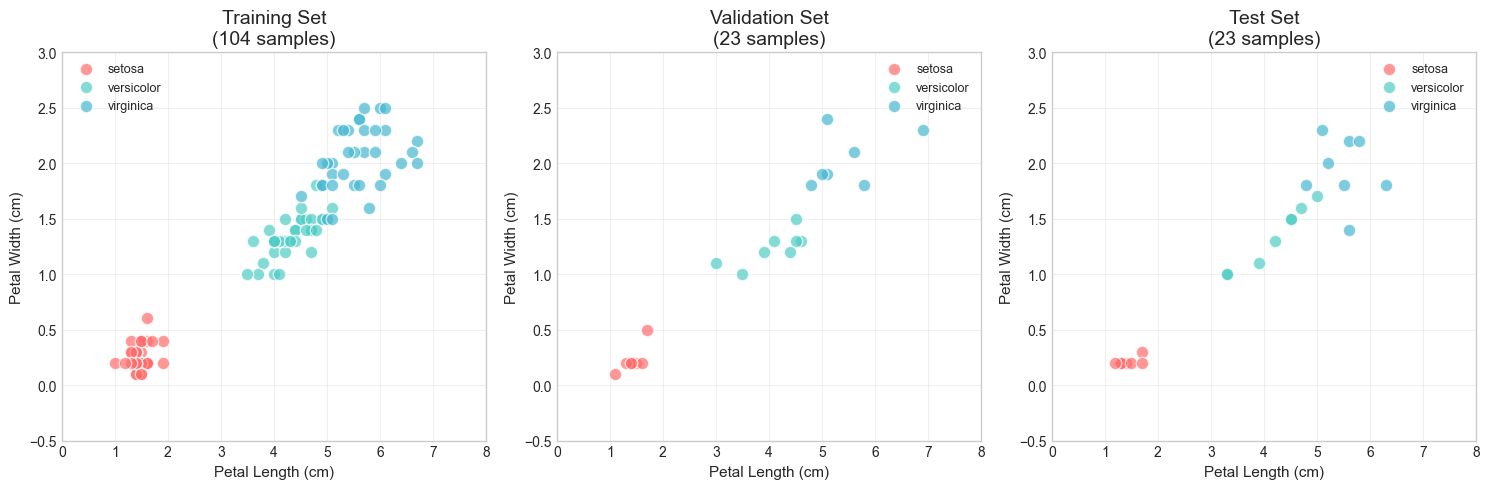

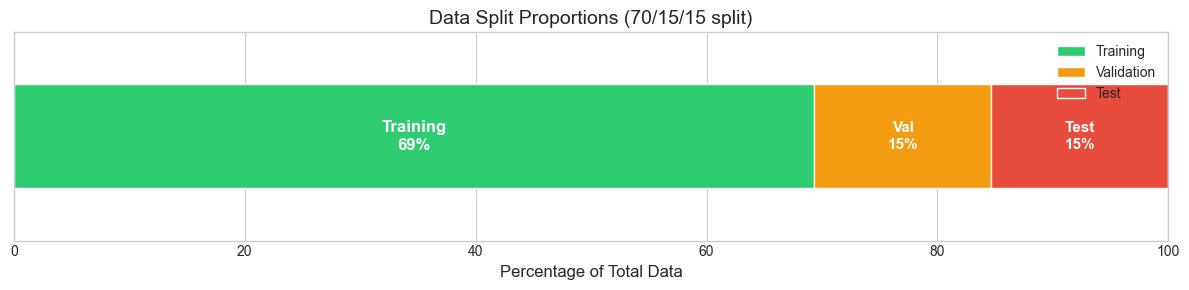

In [8]:
# Visualize the data splits

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Common settings
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

datasets = [
    (X_train, y_train, 'Training Set', f'{len(X_train)} samples'),
    (X_val, y_val, 'Validation Set', f'{len(X_val)} samples'),
    (X_test, y_test, 'Test Set', f'{len(X_test)} samples')
]

for ax, (X_subset, y_subset, title, subtitle) in zip(axes, datasets):
    for i, species in enumerate(iris.target_names):
        mask = y_subset == i
        ax.scatter(X_subset[mask, 2], X_subset[mask, 3], 
                   c=colors[i], s=80, alpha=0.7, 
                   edgecolors='white', linewidth=1,
                   label=species)
    
    ax.set_xlabel('Petal Length (cm)', fontsize=11)
    ax.set_ylabel('Petal Width (cm)', fontsize=11)
    ax.set_title(f'{title}\n({subtitle})', fontsize=14)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 8)
    ax.set_ylim(-0.5, 3)

plt.tight_layout()
plt.show()

# Visual representation of data split proportions
fig, ax = plt.subplots(figsize=(12, 3))

# Create stacked bar showing split
train_pct = len(X_train) / len(X) * 100
val_pct = len(X_val) / len(X) * 100
test_pct = len(X_test) / len(X) * 100

ax.barh(0, train_pct, color='#2ecc71', edgecolor='white', height=0.5, label='Training')
ax.barh(0, val_pct, left=train_pct, color='#f39c12', edgecolor='white', height=0.5, label='Validation')
ax.barh(0, test_pct, left=train_pct+val_pct, color='#e74c3c', edgecolor='white', height=0.5, label='Test')

# Add labels
ax.text(train_pct/2, 0, f'Training\n{train_pct:.0f}%', ha='center', va='center', fontsize=12, fontweight='bold', color='white')
ax.text(train_pct + val_pct/2, 0, f'Val\n{val_pct:.0f}%', ha='center', va='center', fontsize=11, fontweight='bold', color='white')
ax.text(train_pct + val_pct + test_pct/2, 0, f'Test\n{test_pct:.0f}%', ha='center', va='center', fontsize=11, fontweight='bold', color='white')

ax.set_xlim(0, 100)
ax.set_ylim(-0.5, 0.5)
ax.set_xlabel('Percentage of Total Data', fontsize=12)
ax.set_title('Data Split Proportions (70/15/15 split)', fontsize=14)
ax.set_yticks([])
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

### Q. Try training on the test data included and see the performance of the classifier.

### Why Splits Matter: A Preview of Overfitting

**Overfitting** occurs when a model performs well on training data but poorly on new data.

```
Overfitting:
┌─────────────────────────────────────────┐
│  Training Accuracy: 99%  ✓             │
│  Test Accuracy:     60%  ✗             │
│                                        │
│  The model MEMORIZED the training data │
│  instead of learning general patterns  │
└─────────────────────────────────────────┘

Good Generalization:
┌─────────────────────────────────────────┐
│  Training Accuracy: 92%  ✓             │
│  Test Accuracy:     90%  ✓             │
│                                        │
│  The model learned PATTERNS that       │
│  generalize to new data               │
└─────────────────────────────────────────┘
```

This is why we keep a separate **test set** - it tells us how well our model will perform on truly new data!

We'll explore overfitting in detail in the next module (Sheet 2).

## Part E: Putting It All Together - The Complete ML Workflow

Let's walk through a complete example from start to finish:

```
1. LOAD DATA          →  Get your dataset
2. EXPLORE DATA       →  Understand what you're working with
3. PREPARE DATA       →  Create X and y, split into train/val/test
4. CHOOSE A MODEL     →  Select an appropriate ML algorithm
5. TRAIN THE MODEL    →  Let it learn from training data
6. EVALUATE           →  Check performance on validation/test data
7. PREDICT            →  Use model on new data
```

In [ ]:
# Complete Mini-Example: Iris Classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("=" * 60)
print("COMPLETE ML WORKFLOW EXAMPLE")
print("=" * 60)

# Step 1: Load Data
print("\n[Step 1] LOAD DATA")
iris = load_iris()
X, y = iris.data, iris.target
print(f"  Loaded Iris dataset: {X.shape[0]} samples, {X.shape[1]} features")

# Step 2: Explore Data (already done above, so brief summary)
print("\n[Step 2] EXPLORE DATA")
print(f"  Features: {iris.feature_names}")
print(f"  Classes: {list(iris.target_names)}")
print(f"  Samples per class: {np.bincount(y)}")

# Step 3: Prepare Data - Split into train/val/test
print("\n[Step 3] PREPARE DATA")
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.18, random_state=42, stratify=y_temp)
print(f"  Training: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

# Step 4: Choose a Model
print("\n[Step 4] CHOOSE MODEL")
model = KNeighborsClassifier(n_neighbors=5)  # K-Nearest Neighbors with k=5
print(f"  Selected: K-Nearest Neighbors (k=5)")

# Step 5: Train the Model
print("\n[Step 5] TRAIN MODEL")
model.fit(X_train, y_train)
print(f"  Model trained on {len(X_train)} samples")

# Step 6: Evaluate (first on validation, then on test)
print("\n[Step 6] EVALUATE MODEL")
train_acc = accuracy_score(y_train, model.predict(X_train))
val_acc = accuracy_score(y_val, model.predict(X_val))
print(f"  Training Accuracy:   {train_acc*100:.1f}%")
print(f"  Validation Accuracy: {val_acc*100:.1f}%")

# Final test (only once!)
test_acc = accuracy_score(y_test, model.predict(X_test))
print(f"  Test Accuracy:       {test_acc*100:.1f}% (final evaluation)")

# Step 7: Make Predictions on new data
print("\n[Step 7] PREDICT ON NEW DATA")
# Simulate a new flower measurement
new_flower = np.array([[5.0, 3.5, 1.5, 0.2]])  # sepal_len, sepal_wid, petal_len, petal_wid
prediction = model.predict(new_flower)
print(f"  New flower measurements: {new_flower[0]}")
print(f"  Predicted species: {iris.target_names[prediction[0]]}")

print("\n" + "=" * 60)
print("WORKFLOW COMPLETE!")
print("=" * 60)

## Summary: Key Terminology

| Term | Definition |
|------|------------|
| **Machine Learning** | Algorithms that learn patterns from data to make predictions |
| **Supervised Learning** | Learning from labeled examples (input + correct output) |
| **Feature (X)** | Input variables used to make predictions |
| **Label/Target (y)** | The output we want to predict |
| **Sample** | One data point (one row in the dataset) |
| **Feature Matrix** | 2D array of all features for all samples |
| **Classification** | Predicting discrete categories |
| **Regression** | Predicting continuous values |
| **Training Set** | Data used to train the model |
| **Validation Set** | Data used to tune hyperparameters |
| **Test Set** | Data used for final evaluation (use once!) |
| **Overfitting** | Model memorizes training data, fails on new data |
| **Generalization** | Model performs well on unseen data |

---

## Exercises

**Exercise 0.1:** Load a different sklearn dataset (e.g., `load_wine()` or `load_breast_cancer()`) and explore it using the same techniques shown above. What are the features? How many classes are there?

**Exercise 0.2:** Split the Iris dataset using different ratios (e.g., 60/20/20 or 80/10/10). How does this affect the number of samples in each set?

**Exercise 0.3:** Why do we use `stratify=y` when splitting classification datasets? Try splitting without stratification and compare the class distributions.

**Exercise 0.4:** Think of 3 real-world problems. For each, identify:
- What would the features (X) be?
- What would the target (y) be?
- Is it classification or regression?

---

### Next: Module 1 (Sheet 2)
In the next module, we'll dive deeper into **Overfitting and Underfitting** - understanding why models sometimes fail to generalize and how to find the right balance.